# Karachi Air Quality Analysis
**Student:** Joni Kumar Meghwar  
**NIM:** 240411100234  
**Study area:** Karachi, Sindh, Pakistan

This notebook demonstrates the supplied project's Sentinel-5P/openEO workflow using a **single-date NO₂ test (25 August 2026)**. It does not contain a fabricated annual four-pollutant result. The full annual dataset must be collected before annual statistics can be claimed.


In [1]:
import openeo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import geopandas as gpd

print("Everything is ready!")

Everything is ready!


In [2]:
import openeo

connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
)

print(connection)

<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with NullAuth>


In [3]:
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [4]:
collections = connection.list_collection_ids()

print("SENTINEL_5P_L2" in collections)

True


In [5]:
karachi_bbox = {
    "west": 66.65,
    "south": 24.75,
    "east": 67.60,
    "north": 25.65,
    "crs": "EPSG:4326"
}

print("Karachi study area ready")

Karachi study area ready


In [6]:
no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2026-08-25", "2026-08-26"],
    spatial_extent=karachi_bbox,
    bands=["NO2"]
)

print("NO₂ data loaded")

NO₂ data loaded


In [7]:
# Average all available NO₂ observations on 25 August 2026
no2_daily = no2.reduce_dimension(
    dimension="t",
    reducer="mean"
)

print("Daily NO₂ cube created")

Daily NO₂ cube created


In [8]:
no2_daily.download(
    outputfile="karachi_no2_2026-08-25.tif",
    format="GTiff"
)

print("NO₂ GeoTIFF downloaded")

NO₂ GeoTIFF downloaded


In [9]:
import os

print(os.path.exists("karachi_no2_2026-08-25.tif"))

True


In [11]:
%pip install rasterio

   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/25.7 MB 4.8 MB/s eta 0:00:06
   -- ------------------------------------- 1.8/25.7 MB 4.8 MB/s eta 0:00:05
   ---- ----------------------------------- 3.1/25.7 MB 5.3 MB/s eta 0:00:05
   ------- -------------------------------- 4.7/25.7 MB 5.8 MB/s eta 0:00:04
   -------- ------------------------------- 5.8/25.7 MB 5.8 MB/s eta 0:00:04
   ----------- ---------------------------- 7.3/25.7 MB 6.0 MB/s eta 0:00:04
   ------------ --------------------------- 8.1/25.7 MB 5.7 MB/s eta 0:00:04
   -------------- ------------------------- 9.2/25.7 MB 5.6 MB/s eta 0:00:03
   --------------- ------------------------ 10.2/25.7 MB 5.7 MB/s eta 0:00:03
   ----------------- ---------------------- 11.5/25.7 MB 5.7 MB/s eta 0:00:03
   ------------------- -------------------- 12.8/25.7 MB 5.7 MB/s eta 0:00:03
   -------

In [12]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("karachi_no2_2026-08-25.tif") as src:
    no2_array = src.read(1)
    no2_bounds = src.bounds
    no2_transform = src.transform

print("Shape:", no2_array.shape)
print("Minimum:", np.nanmin(no2_array))
print("Maximum:", np.nanmax(no2_array))
print("Mean:", np.nanmean(no2_array))

Shape: (26, 18)
Minimum: 1.21922585e-05
Maximum: 8.553481e-05
Mean: 3.2906097e-05


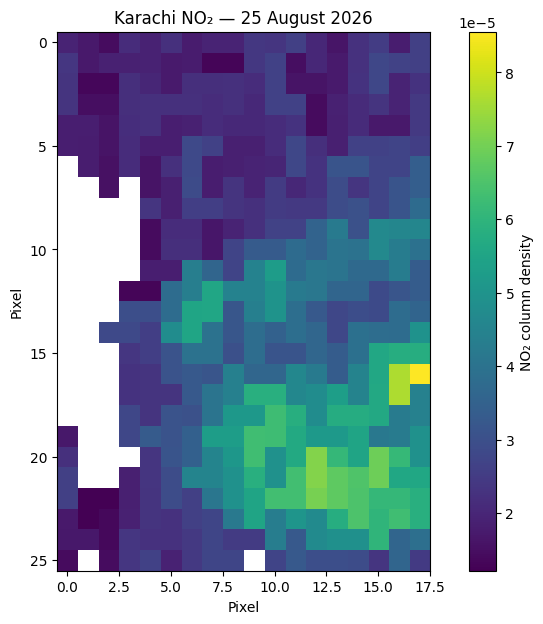

In [13]:
plt.figure(figsize=(10, 7))

plt.imshow(no2_array)
plt.colorbar(label="NO₂ column density")
plt.title("Karachi NO₂ — 25 August 2026")
plt.xlabel("Pixel")
plt.ylabel("Pixel")

plt.show()

In [14]:
import folium
from folium.raster_layers import ImageOverlay

m = folium.Map(
    location=[24.86, 67.01],
    zoom_start=9,
    tiles="OpenStreetMap"
)

bounds = [
    [no2_bounds.bottom, no2_bounds.left],
    [no2_bounds.top, no2_bounds.right]
]

ImageOverlay(
    image=no2_array,
    bounds=bounds,
    opacity=0.65,
    colormap=lambda x: plt.cm.turbo(x),
    interactive=True,
    cross_origin=False
).add_to(m)

folium.Marker(
    [24.8607, 67.0011],
    popup="Karachi, Pakistan"
).add_to(m)

m

In [15]:
print("Minimum:", np.nanmin(no2_array))
print("Maximum:", np.nanmax(no2_array))
print("Mean:", np.nanmean(no2_array))
print("Valid pixels:", np.sum(np.isfinite(no2_array)))
print("Total pixels:", no2_array.size)

Minimum: 1.21922585e-05
Maximum: 8.553481e-05
Mean: 3.2906097e-05
Valid pixels: 419
Total pixels: 468


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from PIL import Image
from folium.raster_layers import ImageOverlay

# Create a mask for valid data
valid = np.isfinite(no2_array)

# Normalize NO2 values
norm = Normalize(
    vmin=np.nanmin(no2_array),
    vmax=np.nanmax(no2_array)
)

# Apply a color map
rgba = plt.cm.turbo(norm(np.nan_to_num(no2_array)))

# Make missing pixels transparent
rgba[~valid, 3] = 0

# Save the colored raster as PNG
Image.fromarray((rgba * 255).astype(np.uint8)).save(
    "karachi_no2_2026-08-25.png"
)

print("Pollution layer created successfully!")

Pollution layer created successfully!


In [17]:
import folium
from folium.raster_layers import ImageOverlay

m = folium.Map(
    location=[24.8607, 67.0011],
    zoom_start=9,
    tiles="OpenStreetMap"
)

bounds = [
    [no2_bounds.bottom, no2_bounds.left],
    [no2_bounds.top, no2_bounds.right]
]

ImageOverlay(
    image="karachi_no2_2026-08-25.png",
    bounds=bounds,
    opacity=0.65,
    interactive=True,
    cross_origin=False
).add_to(m)

folium.Marker(
    [24.8607, 67.0011],
    popup="Karachi — NO₂, 25 August 2026"
).add_to(m)

folium.LayerControl().add_to(m)

m

In [18]:
import pandas as pd
import rasterio

with rasterio.open("karachi_no2_2026-08-25.tif") as src:
    data = src.read(1)
    transform = src.transform

rows = []

for row in range(data.shape[0]):
    for col in range(data.shape[1]):
        value = data[row, col]

        if np.isfinite(value):
            lon, lat = rasterio.transform.xy(
                transform, row, col
            )

            rows.append({
                "date": "2026-08-25",
                "latitude": lat,
                "longitude": lon,
                "NO2_column_density_mol_m2": value
            })

no2_df = pd.DataFrame(rows)

no2_df.to_csv(
    "karachi_no2_2026-08-25.csv",
    index=False
)

print("CSV created!")
print("Rows:", len(no2_df))

no2_df.head()

CSV created!
Rows: 419


,date,latitude,longitude,NO2_column_density_mol_m2
0,2026-08-25,25.632639,66.677282,0.000020
1,2026-08-25,25.632639,66.731845,0.000017
2,2026-08-25,25.632639,66.786409,0.000015
3,2026-08-25,25.632639,66.840972,0.000022
4,2026-08-25,25.632639,66.895536,0.000019


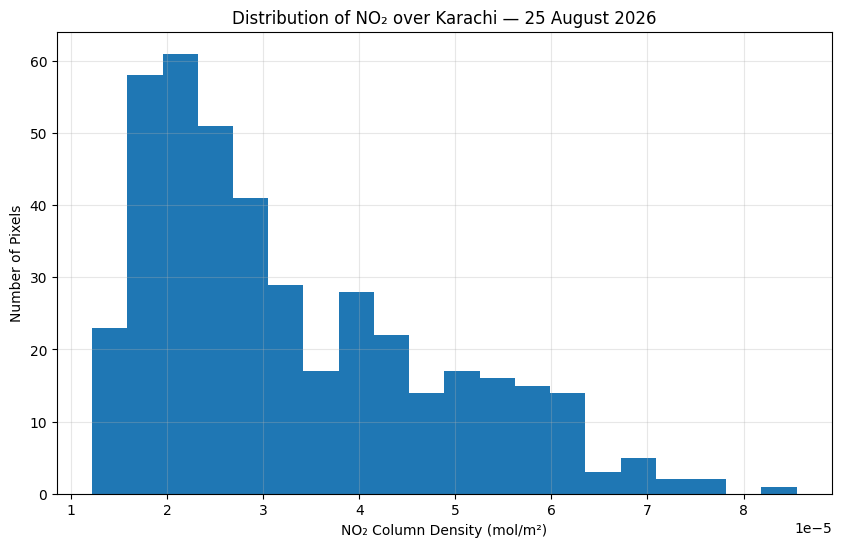

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    no2_df["NO2_column_density_mol_m2"],
    bins=20
)

plt.xlabel("NO₂ Column Density (mol/m²)")
plt.ylabel("Number of Pixels")
plt.title("Distribution of NO₂ over Karachi — 25 August 2026")

plt.grid(alpha=0.3)
plt.show()

In [20]:
statistics = no2_df["NO2_column_density_mol_m2"].describe()

print(statistics)

count    419.000000
mean       0.000033
std        0.000015
min        0.000012
25%        0.000022
50%        0.000028
75%        0.000043
max        0.000086
Name: NO2_column_density_mol_m2, dtype: float64


In [21]:
Q1 = no2_df["NO2_column_density_mol_m2"].quantile(0.25)
Q3 = no2_df["NO2_column_density_mol_m2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = no2_df[
    (no2_df["NO2_column_density_mol_m2"] < lower_bound) |
    (no2_df["NO2_column_density_mol_m2"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of possible outliers:", len(outliers))

Q1: 2.186986694141524e-05
Q3: 4.285529394110199e-05
IQR: 2.098542699968675e-05
Lower bound: -9.608273558114888e-06
Upper bound: 7.433343444063212e-05
Number of possible outliers: 3
